In [1]:
# Librairies to import
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from copy import deepcopy
import pandas as pd
from scipy.interpolate import CubicSpline

In [2]:
class LNS_Variable:
    def __init__(self,rho, v, p):
        self.rho = rho
        self.v = v
        self.p = p
    
    def __mul__(self,alpha):
        self.rho *= alpha
        self.v *= alpha
        self.p *= alpha
        return self

    def __add__(self, other):
        self.rho += other.rho
        self.v += other.v
        self.p += other.p
        return self
    
    def __sub__(self, other):
        self.rho -= other.rho
        self.v -= other.v
        self.p -= other.p
        return self
    
    def __neg__(self):
        self.rho = -self.rho
        self.v = -self.v
        self.p = -self.p
        return self



In [3]:
# sponge layer
def apply_sponge(U, index_z0 = 20, alpha = 0.5):
    # apply a sponge layer for z < z0 and z > zmax - z0
    for i in range(len(U.rho)):
        if i < index_z0 or i > len(U.rho) - index_z0 : 
            U.rho[i] *=  np.exp( - alpha * abs( i - index_z0) / len(U.rho))
            U.p[i] *=  np.exp( - alpha * abs( i - index_z0) / len(U.rho))
            # we have to consider that v is define on the center of each cell
            if (i < len(U.rho)-1) and (i < index_z0 - 1 or i > len(U.rho) - index_z0 + 1) :
                U.v[i] *=  np.exp( - alpha * abs( i - index_z0 + 1/2) / len(U.rho))
    return U

In [4]:
# numerical scheme
def DF_C_2(U, dz, BC, need_BC=True):
    if need_BC:
        BC = [BC[1],BC[-2]]
    else : 
        BC=  [ [], []]
    new_U = np.append(np.append([BC[0]], U), [BC[1]])
    diff_U = new_U[1:] - new_U[:-1]
    return diff_U / dz
   
def DF_DC_2(U, dz, BC, wind, is_reverse=False):
    diff_U = np.zeros(len(U))
    interp_wind = interpolation(wind)
    if is_reverse:
        interp_wind *= -1
    for i in range(len(U)):
        # depending on the sign of wind, the scheme is forward or backward
        if interp_wind[i] > 0 :
            if i < 1:
                diff_U[i] = (U[i] - BC[0]) /dz   
            else :
                diff_U[i] = (U[i] - U[i-1]) /dz  
        else:
            if i >= len(U) - 1:
                diff_U[i] = (BC[-1] - U[i]) /dz   
            else :
                diff_U[i] = (U[i+1] - U[i]) /dz  
    return diff_U
    
'''
def DF_DC_2_backward(U0, dz, BC):
    BC = [ U0[-1:], U0[:1] ]
    U = np.append([BC[0]], U0)
    U = U[1:] - U[:-1]
    return U / dz

def DF_DC_2_forward(U0, dz, BC):
    BC = [ U0[-1:], U0[:1] ]
    U = np.append(U0, [BC[1]])
    U = U[1:] - U[:-1]
    return U / dz


def DF_C_4(U0, dz, BC):
    BC = [ U0[-2:], U0[:2] ]
    U = np.append([BC[0]], U0, [BC[1]])
    Umm = U[:-3]
    Um = U[1:-2]
    Up = U[2:-1]
    Upp = U[3:]
    U = Umm - 27 * Um + 27 * Up - Upp
    return U / (24 * dz)

def DF_DC_4(U0, dz, BC):
    BC = [ U0[-2:], U0[:2] ]
    U = np.append([BC[0]], U0, [BC[1]])
    Umm = U[:-2]
    Um = U[1:-1]
    Up = U[2:]
    U = Umm - 9 * Um + 9 * U - Up
    return U / (6 * dz)
'''
def DF_C_4(U, dz, BC, need_BC= True):
    if not need_BC: 
        BC =  BC[1:-1]
    new_U = np.append(np.append(BC[:int(len(BC)/2)], U), BC[-int(len(BC)/2):])
    Umm = new_U[:-3]
    Um = new_U[1:-2]
    Up = new_U[2:-1]
    Upp = new_U[3:]
    diff_U = Umm - 27 * Um + 27 * Up - Upp
    return diff_U / (24 * dz)

def DF_DC_4(U, dz, BC, wind, is_reverse=False):
    diff_U = np.zeros(len(U))
    interp_wind = interpolation(wind)
    if is_reverse:
        interp_wind *= -1
    for i in range(len(U)):
        # depending on the sign of wind, the scheme is forward or backward
        if interp_wind[i] > 0 :
            if i < 1:
                diff_U[i] = BC[0]/6 + BC[1]/2 - U[0] + U[1]/3 
            elif i == 1 :
                diff_U[i] = BC[1]/6 + U[0]/2 - U[1] + U[2]/3 
            elif i == len(U)-1: 
                diff_U[i] = U[i-2]/6 + U[i-1]/2 - U[i] + BC[-2]/3 
            else :
                diff_U[i] = U[i-2]/6 + U[i-1]/2 - U[i] + U[i+1]/3 
        else:
            if i >= len(U) - 1:
                diff_U[i] = -BC[-1]/3 + BC[-2] - U[i]/2 - U[i-1]/6  
            elif i == len(U) - 2 :
                diff_U[i] = -BC[-2]/3 + U[i+1] - U[i]/2 - U[i-1]/6
            elif i == 0 :
                diff_U[i] = -BC[1]/3 + U[i] - U[i+1]/2 - U[i+2]/6
            else :
                diff_U[i] = -U[i-1]/3 + U[i] - U[i+1]/2 - U[i+2]/6
                
    return diff_U / dz

def interpolation(U):
    # compute the value at point i+1/2 for i in [0,N-1]
    BC = [U[0],U[-1]]
    U = np.append(np.append([BC[0]], U), [BC[1]])
    U = U[1:] + U[:-1]
    return U / 2

In [42]:
# Definition of function that describes the Linearised Navier-Stokes 

def DF_sigma_v(V, l, mu, dz, BC, DF_C, DF_DC):
    # compute the divergence of the stress tensor stress tensor
    dV = DF_C(V, dz, BC)
    return DF_C( (l+2*mu) * dV, dz, BC, False) 

'''
def DF_kappaDT2(T, kappa, gamma, dz, BC):
    # compute the divergene of the temperaure
    dT = DF_DC_2_backward(T, dz, BC)
    return DF_DC_2_forward(kappa * (gamma-1) * dT, dz, BC) 
'''

def DF_kappaDT(T, kappa, gamma, dz, BC, DF_C, DF_DC):
    # compute the divergene of the temperaure
    dT = DF_C(T, dz, BC)
    aux = np.append( np.append([kappa[0] * (gamma[0]-1)], kappa * (gamma-1)), [kappa[-1] * (gamma[-1]-1)])
    return DF_C( (aux[1:]+ aux[:-1])/2  * dT, dz, BC, False) 


def DF_Sigma_C(U1, U0, dz, gamma, is_reverse, DF_C, DF_DC):
    # initialise
    S  = np.zeros((3,len(U1.rho)))
    
    BC1 = [0,0,0,0]                                           # Points -2, -1, N+1, N+2                       
    BC_v0 = [U0.v[0], U0.v[0], U0.v[-1], U0.v[-1]]            # Points -2, -1, N+1, N+2 
    BC_rho0 = [U0.rho[0], U0.rho[0], U0.rho[-1], U0.rho[-1]]  # Points -2, -1, N+1, N+2 
    BC_p0 = [U0.p[0], U0.p[0], U0.p[-1], U0.p[-1]]            # Points -2, -1, N+1, N+2 
    
    # compute the contribution on density
    S[0,:] = U0.rho * DF_C(U1.v, dz, BC1)                                              # rho0 div v1
    S[0,:] += interpolation(U1.v) * DF_DC(U0.rho, dz, BC_rho0, U0.v, is_reverse)  # v1 grad rho0
    S[0,:] +=  U1.rho * DF_C(U0.v, dz, BC_v0)                                          # rho1 div v0
    S[0,:] += interpolation(U0.v) * DF_DC(U1.rho, dz, BC1, U0.v, is_reverse)    # v0 grad rho1 
    # compute the contribution on qunatity of mvt
    S[1,:-1] = (U0.rho[1:]+U0.rho[:-1])/2 * U0.v * DF_DC(U1.v, dz, BC1, U0.v, is_reverse)    # roh0 v0 . div v1
    S[1,:-1] += DF_C_2(U1.p, dz, BC1, False)                                                 # grap p1
    # compute the contribution on pressure
    S[2,:] = gamma * U1.p * DF_C(U0.v, dz, BC_v0)                                  # gamma p1 div v0
    S[2,:] += interpolation(U1.v) * DF_DC(U0.p, dz, BC_p0, U0.v, is_reverse)  # v0 grad p1
    S[2,:] +=  gamma * U0.p * DF_C(U1.v, dz, BC1)                                  # gamma p0 div v1
    S[2,:] += interpolation(U0.v) * DF_DC(U1.p, dz, BC1, U0.v, is_reverse)  # v1 grad p0
    
    return LNS_Variable(S[0,:], S[1,:-1], S[2,:])


def DF_Sigma_D(U1, U0, dz, T0, g, l, mu, kappa, gamma, R, DF_C, DF_DC):
    # initiliase
    S  = np.zeros((3,len(U1.rho)))
    
    BC1 = [0,0,0,0]                                           # Points -2, -1, N+1, N+2
    BC_v0 = [U0.v[0], U0.v[0], U0.v[-1], U0.v[-1]]            # Points -2, -1, N+1, N+2 
    
    T1 = (U1.p + U0.p) / R / (U1.rho + U0.rho) - T0
    
    sigma_V0 = (2*mu + l) * DF_C(U0.v, dz, BC_v0)
    sigma_Vp = (2*mu + l) * DF_C(U1.v, dz, BC1)
    
    # compute the contribution on density
    S[0,:] = 0
    # compute the contribution on quantity of mvt 
    S[1,:-1] = DF_sigma_v( U1.v, l, mu, dz, BC1, DF_C, DF_DC)                       # div Sigma_v v1
    # compute the contribution on pressure
    S[2,:] = DF_kappaDT(T1, kappa, gamma, dz, BC1, DF_C, DF_DC)                     # div (kappa (gamma-1) grad T)
    S[2,:] += sigma_V0 * DF_C(U1.v, dz, BC1) + sigma_Vp * DF_C(U0.v, dz, BC_v0)     # Sigma_v v0: grad v1 + Sigma_v v1 : grad v0

    return LNS_Variable(S[0,:], S[1,:-1], S[2,:])


def G(U1, U0, dz, is_reverse, DF_C, DF_DC):
    # initialise
    GU = np.zeros((3,len(U1.rho)))
    rho1_demi = (U1.rho[1:]+U1.rho[:-1])/2
    g_demi = (g[1:]+g[:-1])/2
    rho0_demi = (U0.rho[1:]+U0.rho[:-1])/2
    
    BC_v0 = [U0.v[0], U0.v[0], U0.v[-1], U0.v[-1]]            # Points -2, -1, N+1, N+2 

    # compute the contribution on density
    GU[0,:] = 0
    # compute the contribution on quantity of mvt
    GU[1,:-1] = rho1_demi * g_demi                                                                 # rho1 g
    GU[1,:-1] += (rho0_demi * U1.v + rho1_demi * U0.v) * DF_DC(U0.v, dz, BC_v0, U0.v, is_reverse)  # (rho0v1 + rho1v0) div v0
    # compute the contribution on pressure
    GU[2,:] = 0
    
    return LNS_Variable(GU[0,:], GU[1,:-1], GU[2,:])


def F(U1, it, source, n):
    # define source term
    f = np.zeros((3,n))
    source_time = source[0]
    source_spatial = source[1]
    # compute the contribution on density
    for i in range(len(f[0])):
        f[0,i] = source_time[it]/100 * source_spatial[i]
    # compute the contribution on quantity of mvt
    f[1,:-1] = U1.v * (f[0,1:]+f[0,:-1])/2
    return LNS_Variable(f[0,:], f[1,:-1], f[2,:])

In [43]:
# Definition of resolution spatial
def get_RHS(U1, t, U0, T0, g, l, mu, kappa, gamma, R, dz, dt, source, is_reverse, order_DF=4):
    if order_DF == 4:
        DF_DC = DF_DC_4
        DF_C = DF_C_4
    else :
        DF_DC = DF_DC_2
        DF_C = DF_C_2
        
    return F(U1, int(abs(t/dt)), source, len(U1.rho)) + G(U1, U0, dz, is_reverse, DF_C, DF_DC) \
        + DF_Sigma_D(U1, U0, dz, T0, g, l, mu, kappa, gamma, R, DF_C, DF_DC) \
        - DF_Sigma_C(U1, U0, dz, gamma, is_reverse, DF_C, DF_DC)

In [44]:
# Definition of temporal scheme - Runge Kutta of order 4
def RK4(f, U_t, T_init, Tmax,*args):
    fig,ax = plt.subplots(3,1, figsize=(10,7))
    dt = args[9]
    args = list(args) + [False] # add the value of is_reverse
    if Tmax < T_init:
        dt *= -1
        args[-1] = True 
    
    for t in np.arange(T_init,Tmax,dt):
        k1 = f(U_t, t, *args)
        aux = k1 * (dt / 2.)
        k2 = f( U_t + aux, t + dt / 2., *args)
        aux = k2 * (dt / 2.)
        k3 = f( U_t + aux, t + dt / 2., *args)
        aux = k3 * (dt)
        k4 = f( U_t + aux, t + dt, *args)
        
        U_t = U_t + (k1 + k2*2 + k3*2 + k4) * (dt/6)
        U_t = apply_sponge(U_t)

        if t % 10 < 1e-4 : 
            ax[0].plot(z,U_t.rho, label=str(t))
            ax[1].plot(z,U_t.p)
            ax[2].plot( (z[1:] + z[:-1])/2,U_t.v)

    fig.legend()
    return t, U_t

# Definition of temporal scheme - Euler explicit
def EE(f, U_t, T_init, Tmax, *args):
    fig,ax = plt.subplots(3,1)
    dt = args[9]
    if Tmax < T_init:
        dt *= -1
    
    for t in np.arange(T_init,Tmax,dt):
        U_t = U_t +  f(U_t, t, *args) * dt
        if t % 10 < 1e-4 : 
            ax[0].plot(z,U_t.rho, label=str(t))
            ax[1].plot(z,U_t.p)
            ax[2].plot( (z[1:] + z[:-1])/2,U_t.v)

    ax[0].set_xlabel("Altitude")
    ax[1].set_xlabel("Altitude")
    ax[2].set_xlabel("Altitude")
    ax[0].set_ylabel("Density")
    ax[1].set_ylabel("Pressure")
    ax[2].set_ylabel("Velocity")
    ax[0].grid()
    ax[1].grid()
    ax[2].grid()
    fig.legend()
    return t, U_t

# Define the model

In [45]:
# The spatio-temporel domain

# define the space
z0 = 0
zmax = 150e3
h = 1.2e3

z = np.arange(z0,zmax+h,h)


# define receivers
d_receivers = 5e3 # distance between 2 receivers
r = np.arange(z0+d_receivers, zmax, d_receivers)


# define Time
t = 0
T_init = 0
Tmax = 50
dt = 0.01

# Definition de la source

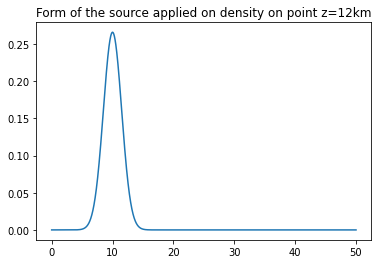

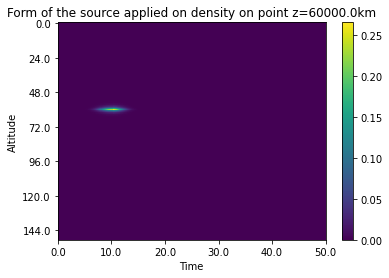

In [46]:
# set the source
iz_source = 50
t_ax = np.arange(T_init,Tmax+2*dt,dt)
source = scipy.stats.norm.pdf(t_ax,10,1.5)

dist_z = abs(z - z[iz_source])
factor_source = np.exp(-dist_z/1000)

plt.plot(t_ax, source)
plt.title("Form of the source applied on density on point z=12km")
plt.show()

# plot the source in time and space
total_source = np.zeros((len(z), len(t_ax)))
for t in t_ax : 
    for i in range(len(z)):
        total_source[i,int(t/dt)] = source[int(t/dt)] * factor_source[i]


fig, ax = plt.subplots()
plt.imshow(total_source, aspect='auto')
plt.colorbar()
plt.title("Form of the source applied on density on point z="+ str(z[iz_source])+"km")
plt.xticks(range(0,len(t_ax),1000), t_ax[0:len(t_ax):1000])
plt.yticks(range(0,len(z),20), z[0:len(z):20]/1000)
plt.xlabel("Time")
plt.ylabel("Altitude")

source = [source, factor_source]

# Test 1 : Model is constant

In [47]:
# The parameters

# define model parameters
rho0 = 1.04898036 * np.ones(len(z))
v0 = -4.33914709 * np.ones(len(z)) #0.00745178154 * np.ones(len(z))
p0 =88714.4844 * np.ones(len(z))
T0 = 294.375305 * np.ones(len(z))
c = 344.108887 * np.ones(len(z))
g = 0*9.81084824 * np.ones(len(z))
mu = 1.27685234e-05 * np.ones(len(z))
kappa = 0.0258137602 * np.ones(len(z))
gamma = 1.40011787 * np.ones(len(z))
eta = 2.72986326e-05 * np.ones(len(z))
R = 287

l = eta - (2/3)*mu

# define vectors of the system
v0_demi = (v0[1:] + v0[:-1])/2
U0 = LNS_Variable(rho0, v0_demi, p0) 
U1 = LNS_Variable(np.zeros(len(z)), np.zeros(len(z)-1), np.zeros(len(z))) 

Text(0.5, 0.98, 'A T = 0, the background')

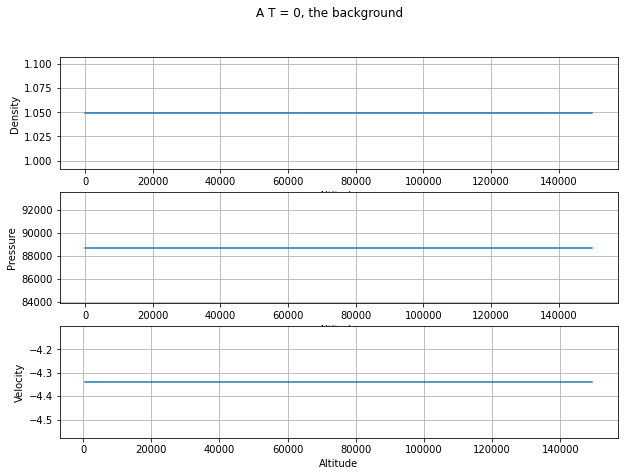

In [48]:
# Plot the model
fig,ax = plt.subplots(3,1, figsize=(10,7))
ax[0].plot(z,U0.rho)
ax[1].plot(z,U0.p)
ax[2].plot( (z[1:] + z[:-1])/2,U0.v)
ax[0].set_xlabel("Altitude")
ax[1].set_xlabel("Altitude")
ax[2].set_xlabel("Altitude")
ax[0].set_ylabel("Density")
ax[1].set_ylabel("Pressure")
ax[2].set_ylabel("Velocity")
ax[0].grid()
ax[1].grid()
ax[2].grid()
fig.suptitle("A T = 0, the background")

#### Resolve the LNS

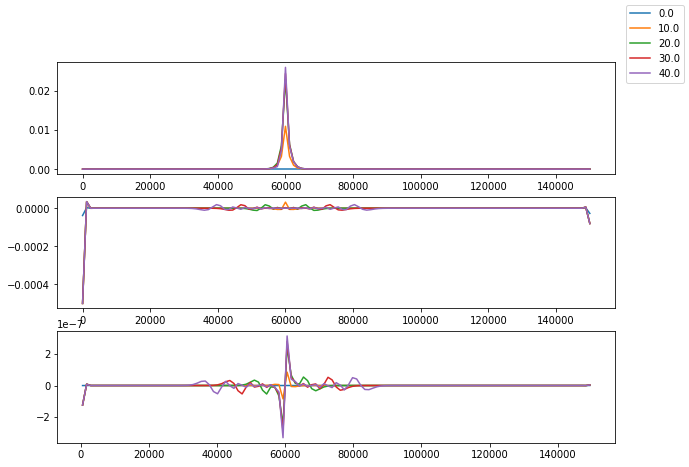

In [49]:
# Resolution in a 1d case
t_end, U_end = RK4(get_RHS, U1, T_init, Tmax, U0, T0, g, l, mu, kappa, gamma, R, h, dt, source)

#### Plot the final state

Text(0.5, 0.98, 'Perturbation after Tmax = 50')

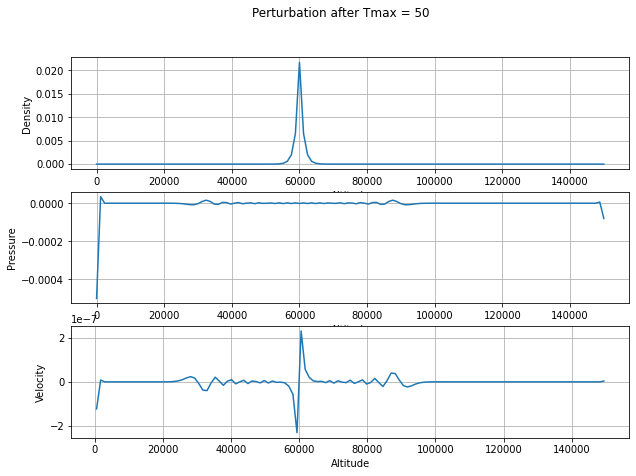

In [25]:
fig,ax = plt.subplots(3,1, figsize=(10,7))
fig
ax[0].plot(z,U_end.rho)
ax[1].plot(z,U_end.p)
ax[2].plot( (z[1:] + z[:-1])/2,U_end.v)
ax[0].set_xlabel("Altitude")
ax[1].set_xlabel("Altitude")
ax[2].set_xlabel("Altitude")
ax[0].set_ylabel("Density")
ax[1].set_ylabel("Pressure")
ax[2].set_ylabel("Velocity")
ax[0].grid()
ax[1].grid()
ax[2].grid()
fig.suptitle("Perturbation after Tmax = "+ str(Tmax))

#### Modify the right hand sided to backpropagate and get again the initial state

In [14]:
# Definition of resolution spatial
#def get_minus_RHS(U1, t, U0, T0, g, l, mu, kappa, gamma, R, dz, dt, source):
#    return - get_RHS(U1, t, U0, T0, g, l, mu, kappa, gamma, R, dz, dt, source)

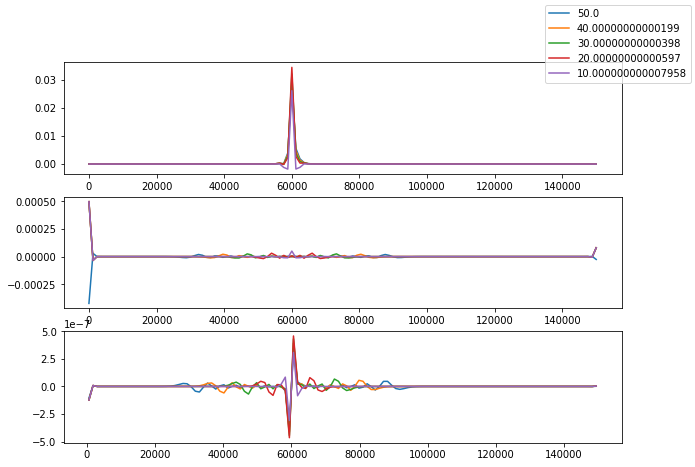

In [15]:
# Resolution in a 1d case
U_tmax = deepcopy(U_end)
t_start, U_start = RK4(get_RHS, U_end, Tmax, T_init, U0, T0, g, l, mu, kappa, gamma, R, h, dt, source)

Text(0.5, 0.98, 'After Tmax = 0')

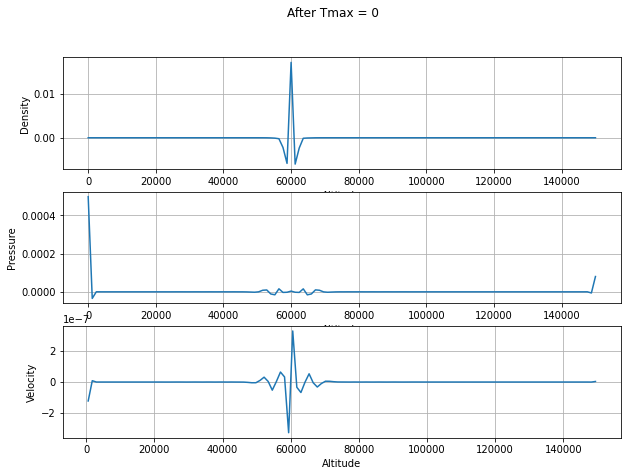

In [16]:
fig,ax = plt.subplots(3,1, figsize=(10,7)
                     )
ax[0].plot(z,U_start.rho)
ax[1].plot(z,U_start.p)
ax[2].plot( (z[1:] + z[:-1])/2,U_start.v)
ax[0].set_xlabel("Altitude")
ax[1].set_xlabel("Altitude")
ax[2].set_xlabel("Altitude")
ax[0].set_ylabel("Density")
ax[1].set_ylabel("Pressure")
ax[2].set_ylabel("Velocity")
ax[0].grid()
ax[1].grid()
ax[2].grid()
fig.suptitle("After Tmax = 0")

# Test 2: the model is not constant on z axis

In [17]:
# define the model thanks to a MSISE file

path_file = "/home/deos/s.gerier/PROJECTS/SIMULATIONS/ATMOSPHERIC_MODELS/MSISE/msisehwm_wrapper/OUTPUT/Flores_atmosphere_500km_86p2_4.dat"
data = np.genfromtxt(path_file, skip_header=3)#,delimiter=[7,7,7,7,7,7,7,3,3,3,3,5,5,7,7,7])
df = pd.DataFrame(data, columns =["z[m]", "rho[kg/(m^3)]", "T[K]", "c[m/s]", "p[Pa]", "H[m]", "g[m/(s^2)]", "N^2[rad^2/s^2]", "kappa[J/(s.m.K)]", "mu[kg(s.m)]", "mu_vol[kg/(s.m)]", "w_M[m/s]", "w_Z[m/s]", "w_P[m/s]", "c_p[J/(mol.K)]", "c_v[J/(mol.K)]", "gamma"])

physical_parameters = ["rho[kg/(m^3)]", "T[K]", "c[m/s]", "p[Pa]", "g[m/(s^2)]", "kappa[J/(s.m.K)]", "mu[kg(s.m)]", "mu_vol[kg/(s.m)]", "gamma"]
interp_physical_param = []
for param in physical_parameters:
    if param == "rho[kg/(m^3)]" or param == "p[Pa]" : 
        cs = CubicSpline(df["z[m]"], np.log(df[param]))
        interp_physical_param += [np.exp(cs(z))]
    else : 
        cs = CubicSpline(df["z[m]"], df[param])
        interp_physical_param += [cs(z)]

[rho0, T0, c, p0, g, kappa, mu, eta, gamma] = interp_physical_param
v0 = 0 * np.ones(len(z))
R = 287

l = eta - (2/3)*mu

# define vectors of the system
v0_demi = (v0[1:] + v0[:-1])/2
U0 = LNS_Variable(rho0, v0_demi, p0) 
U1 = LNS_Variable(np.zeros(len(z)), np.zeros(len(z)-1), np.zeros(len(z))) 

Text(0.5, 0.98, 'A T = 0, the background')

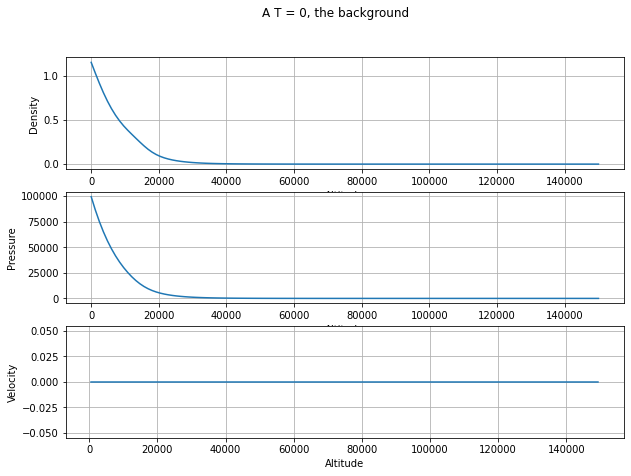

In [18]:
# Plot the model
fig,ax = plt.subplots(3,1, figsize=(10,7))
ax[0].plot(z,U0.rho)
ax[1].plot(z,U0.p)
ax[2].plot( (z[1:] + z[:-1])/2,U0.v)
ax[0].set_xlabel("Altitude")
ax[1].set_xlabel("Altitude")
ax[2].set_xlabel("Altitude")
ax[0].set_ylabel("Density")
ax[1].set_ylabel("Pressure")
ax[2].set_ylabel("Velocity")
ax[0].grid()
ax[1].grid()
ax[2].grid()
fig.suptitle("A T = 0, the background")

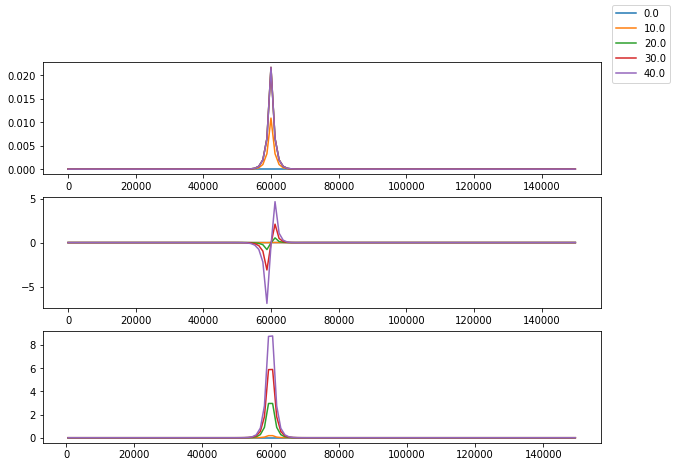

In [19]:
# Resolution in a 1d case
t_end, U_end = RK4(get_RHS, U1, T_init, Tmax, U0, T0, g, l, mu, kappa, gamma, R, h, dt, source)

# Adjoint equations

In [ ]:
def dchi(U1,obs):
    n = len(U1.rho)
    U = np.zeros((3, n))

    U[0,0:n:dr] = - obs.rho # complete
    U[1,0:n-1:dr] = - obs.v # complete
    U[2,0:n:dr] = - obs.p   # complete

def DF_kappaDp(p, kappa, gamma, dz, BC, DF_C, DF_DC):
    # compute the divergene of the temperaure
    dp = DF_C(p, dz, BC)
    aux = np.append( np.append([kappa[0] * (gamma[0]-1)], kappa * (gamma-1)), [kappa[-1] * (gamma[-1]-1)])
    return DF_C( (aux[1:]+ aux[:-1])/2  * dp, dz, BC, False) 


In [ ]:
def get_adjoint_RHS(U1star, t, U0, T0, g, l, mu, kappa, gamma, R, dz, dt, source, is_reverse, order_DF=4):
    if order_DF == 4:
        DF_DC = DF_DC_4
        DF_C = DF_C_4
    else :
        DF_DC = DF_DC_2
        DF_C = DF_C_2
        
    U = np.zeros((3, len(Ustar.rho)))
    
    
    BCstar = [0,0,0,0]
    BC_v0 = [U0.v[0], U0.v[0], U0.v[-1], U0.v[-1]]
    BC_rho0 = [U0.rho[0], U0.rho[0], U0.rho[-1], U0.rho[-1]]
    BC_p0 = [U0.p[0], U0.p[0], U0.p[-1], U0.p[-1]]
    
    ddp = DF_kappaDp(Ustar.p, kappa, gamma, dz, BC, DF_C, DF_DC)
    
    Frho1
    Fadjoint = dchi()
    
    U[0,:] = - U star.rho * DF_C(U0.v, dz, BCstar)                                        # rho* div v0
    U[0,:] += DF_C(  (Ustar.rho[1:]+Ustar.rho[:-1])/2 * U0.v, dz, BCstar)         # div (rho* v0) 
    U[0,:] += g * interpolation(Ustar.v)                                                # g . m*
    U[0,:] -=  interpolation(U0.v) * DF_C(U0.v, dz, BCstar) * interpolation(Ustar.v)    # (v0 . div v0) . m*
    U[0,:] += T0 / U0.rho * ddp                                                         # To/rho0 div( (1-gamma) kappa grad p)
    
    U[1,:-1] = - (Ustar.rho[1:]+Ustar.rho[:-1])/2 * DF_C(U0.rho, dz, BC_rho0, False)    # rho* grad(rho0)
    U[1,:-1] += DF_C( U0.rho * U_star.rho, dz, BCstar)                                  # div (rho0 rho*)
    U[1,:-1] += DF_sigma_v( Ustar.v, l, mu, dz, BCstar, DF_C, DF_DC)                    # div (Sigma (m*))
    U[1,:-1] -= (U0.rho[1:]+U0.rho[:-1])/2 * DF_DC(U0.v, dz, BC_v0, U0.v) * Ustar.v     # rho0 div (v0) m*
    U[1,:-1] += Frho1 *  Ustar.v                                                        # F m* 
    U[1,:-1] += Ustar.p * DF_C(U0.p, dz, BC_p0, False)                                  # p* div p0
    
    U[2,:] = DF_C(Ustar.v, dz, BCstar)                                         # div m*
    U[2,:] -= gamma * Ustar.p * DF_C(U0.v, dz, BC_v0)                          # gamma p* div v0
    U[2,:] += DF_C(  (Ustar.p[1:]+Ustar.p[:-1])/2 * U0.v, dz, BCstar)          # div(p* v0)
    U[2,:] += ddp / (R * U0.rho)                                               # 1/ ( (gamma-1) cv rho0) div( (1-gamma) kappa grad p)
    
    return LNS_Variable(U[0,:], U[1,:-1], U[2,:]) 

# Kernel computations

## Other tests / verifications

### Test schéma numérique avec une équation d'advection

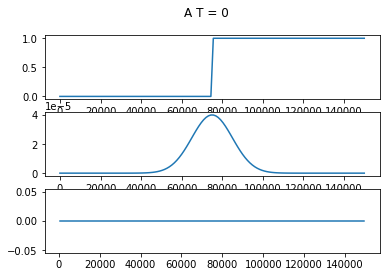

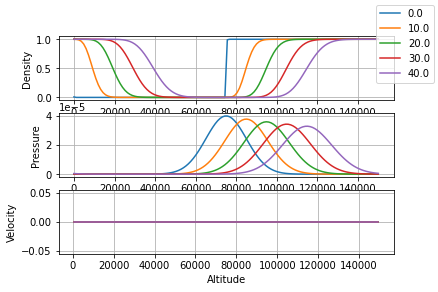

In [20]:
# Definition of temporal scheme - Euler explicit
def EE(f, U_t, T_init, Tmax, dt, *args):
    fig,ax = plt.subplots(3,1)
    args = list(args) + [False]
    if Tmax < T_init:
        dt *= -1
        args[-1] = True
        
    for t in np.arange(T_init,Tmax,dt):
        U_t = U_t +  f(U_t, t, *args) * dt
        if t % 10 < 1e-4 : 
            ax[0].plot(z,U_t.rho, label=str(t))
            ax[1].plot(z,U_t.p)
            ax[2].plot( (z[1:] + z[:-1])/2,U_t.v)

    ax[0].set_xlabel("Altitude")
    ax[1].set_xlabel("Altitude")
    ax[2].set_xlabel("Altitude")
    ax[0].set_ylabel("Density")
    ax[1].set_ylabel("Pressure")
    ax[2].set_ylabel("Velocity")
    ax[0].grid()
    ax[1].grid()
    ax[2].grid()
    fig.legend()
    return t, U_t

def get_advection_RHS(u, t, dz, a):
    aux = (u.rho[1:] + u.rho[:-1])/2
    rho =  - DF_C_2(aux,dz, 1) * a
    aux = (u.v[1:] + u.v[:-1])/2
    v =  - DF_C_2(aux,dz, 1) * a
    aux = (u.p[1:] + u.p[:-1])/2
    p =  - DF_C_2(aux,dz, 1) * a
    return LNS_Variable(rho,v,p)

def get_advection_RHS(u, t, dz, a, is_reverse= 0):
    wind  = a * np.ones(len(u.p))
    if is_reverse : 
        wind *= -1 
    rho =  - DF_DC_2(u.rho,dz, [u.rho[-1], u.rho[0]], wind) * a
    v =  - DF_DC_2(u.v,dz, [u.v[-1], u.v[0]], wind) * a
    p =  - DF_DC_2(u.p,dz, [u.p[-1], u.p[0]], wind) * a
    return LNS_Variable(rho,v,p)

rho0 = np.zeros(len(z))
rho0[int(len(z)/2):] = 1
v0 = np.zeros(len(z)-1)
p0 = scipy.stats.norm.pdf(z,75e3,10e3) 
U0 = LNS_Variable(rho0, v0, p0) 

dt = 0.01

fig,ax = plt.subplots(3,1)
ax[0].plot(z,U0.rho)
ax[1].plot(z,U0.p)
ax[2].plot( (z[1:] + z[:-1])/2,U0.v)
fig.suptitle("A T = 0")
plt.show()

t_end, U_end = EE(get_advection_RHS, U0, T_init, Tmax, dt, h, 1e3)


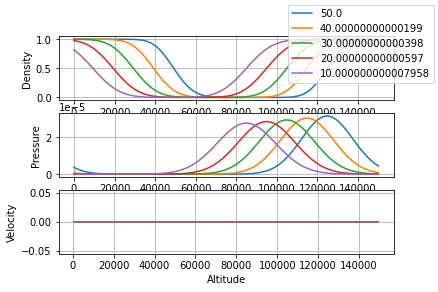

In [21]:
t_start, U_start = EE(get_advection_RHS, U_end, Tmax, T_init, dt, h, 1e3)